# Predictive Maintenance EDA
## AI4I 2020 Manufacturing Dataset

This notebook explores the AI4I 2020 Predictive Maintenance dataset 
to identify patterns and key factors that lead to machine failures.

**Dataset source:** UCI Machine Learning Repository  
**Goal:** Identify features that predict machine failure

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Data Overview

In [4]:
print(f"Shape: {df.shape}")

Shape: (10000, 14)


In [5]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [6]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [8]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## 3. Target Variable Analysis

In [16]:
# Failure rate
df['Machine failure'].value_counts(normalize=True)*100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

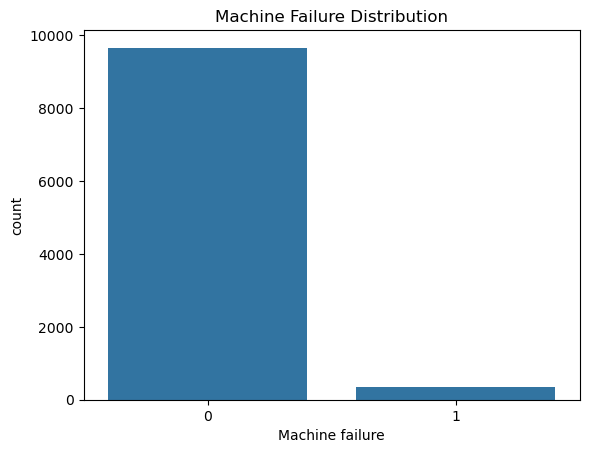

In [46]:
sns.countplot(data=df, x='Machine failure')
plt.title('Machine Failure Distribution')
plt.show()

**Finding:** The dataset is highly imbalanced — only 3.39% of records 
represent machine failures. This is typical for real-world predictive 
maintenance data. Standard accuracy metric will be misleading — 
F1-score and recall should be used instead.

### 4. Feature Analysis

In [33]:
# Average Machine failure by Air temperature [K]', 'Rotational speed [rpm]' and'Tool wear [min]
df.groupby('Machine failure')[['Air temperature [K]', 'Rotational speed [rpm]','Tool wear [min]']].mean().reset_index()

,Machine failure,Air temperature [K],Rotational speed [rpm],Tool wear [min]
0,0,299.973999,1540.260014,106.693717
1,1,300.886431,1496.486726,143.781711


In [25]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

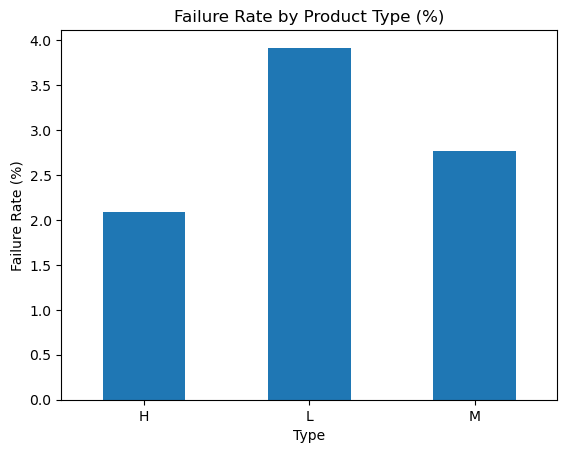

In [50]:
df.groupby('Type')['Machine failure'].mean().mul(100).plot(
    kind='bar', title='Failure Rate by Product Type (%)')
plt.ylabel('Failure Rate (%)')
plt.xticks(rotation=0)
plt.show()

**Finding:** High quality products (H) show the lowest failure rate, 
while Low quality products (L) show the highest, suggesting 
product quality is a relevant factor in machine reliability.

In [35]:
# TWF, HDF, PWF, OSF, RNF
print(df['TWF'].value_counts(normalize=True)*100)
print(df['HDF'].value_counts(normalize=True)*100)
print(df['PWF'].value_counts(normalize=True)*100)
print(df['OSF'].value_counts(normalize=True)*100)
print(df['RNF'].value_counts(normalize=True)*100)

TWF
0    99.54
1     0.46
Name: proportion, dtype: float64
HDF
0    98.85
1     1.15
Name: proportion, dtype: float64
PWF
0    99.05
1     0.95
Name: proportion, dtype: float64
OSF
0    99.02
1     0.98
Name: proportion, dtype: float64
RNF
0    99.81
1     0.19
Name: proportion, dtype: float64


In [40]:
df[['TWF','HDF','PWF','OSF','RNF']].sum().sort_values(ascending=False)

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

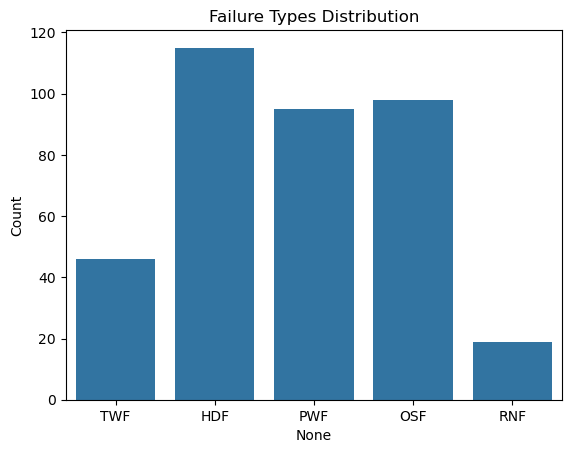

In [7]:
failure_types = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].sum()

sns.barplot(x=failure_types.index, y=failure_types.values)
plt.title('Failure Types Distribution')
plt.ylabel('Count')
plt.show()

**Finding:** Heat Dissipation Failure (HDF) is the most frequent 
failure type, followed by Overstrain Failure (OSF) and Power Failure (PWF). Random Failures (RNF) are the rarest, which is 
expected as they occur independently of process parameters. 
This suggests that thermal management is the most critical 
area for preventing equipment failures.

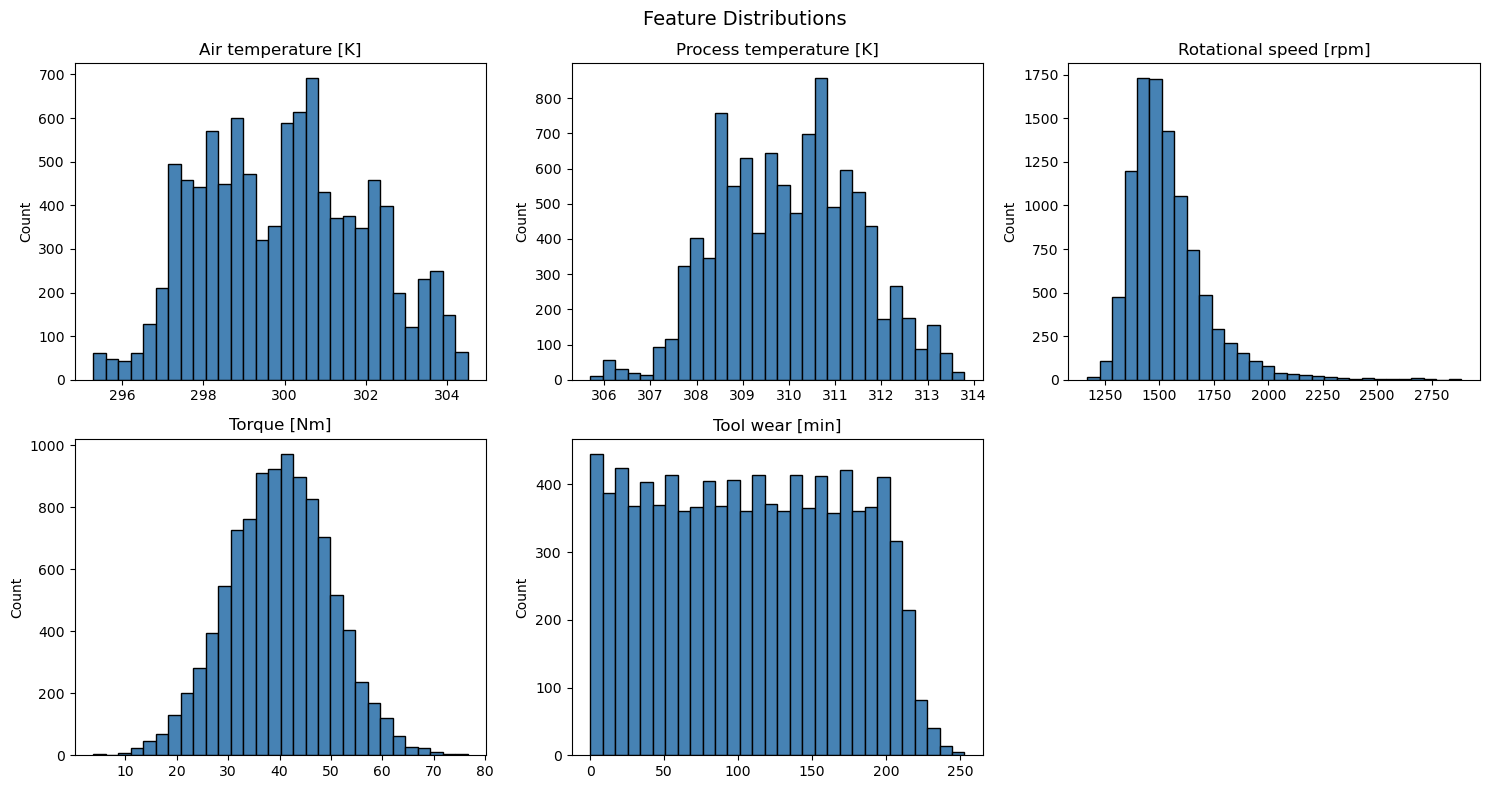

In [51]:
cols = ['Air temperature [K]', 'Process temperature [K]', 
        'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(cols):
    ax = axes[i//3][i%3]
    ax.hist(df[col], bins=30, edgecolor='black', color='steelblue')
    ax.set_title(col)
    ax.set_ylabel('Count')

axes[1][2].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

**Finding:** Most features show approximately normal distributions. 
Rotational Speed shows a slight right skew, indicating some machines 
operate at unusually high speeds. Tool Wear appears more uniformly 
distributed, suggesting machines are monitored and replaced at 
regular intervals rather than run to failure.

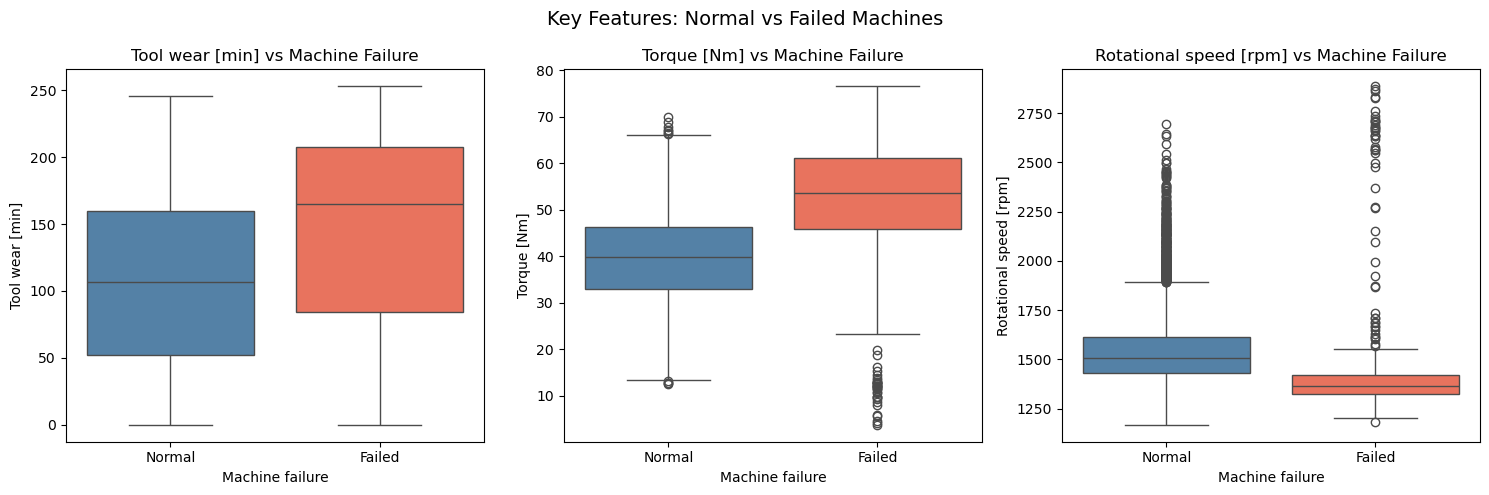

In [11]:
cols = ['Tool wear [min]', 'Torque [Nm]', 'Rotational speed [rpm]']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cols):
    sns.boxplot(
        data=df, 
        x='Machine failure', 
        y=col,
        hue='Machine failure',
        palette=['steelblue', 'tomato'],
        ax=axes[i],
        legend=False
    )
    
    axes[i].set_title(f'{col} vs Machine Failure')
    axes[i].set_xticks([0, 1], labels=['Normal', 'Failed'])  
plt.suptitle('Key Features: Normal vs Failed Machines', fontsize=14)
plt.tight_layout()
plt.show()

**Finding:** Failed machines show notably higher Torque and Tool Wear 
compared to normal operations, while Rotational Speed tends to be 
lower. This pattern is consistent with an overloaded machine 
operating under high stress — high torque at low speed combined 
with worn tooling is a strong signal of impending failure.

Failed machines show significantly higher Torque (median ~53 Nm 
vs ~40 Nm for normal) and lower Rotational Speed (median ~1350 rpm 
vs ~1500 rpm). The outliers in both groups represent extreme 
operating conditions and should be retained — in predictive 
maintenance, anomalous readings are often early indicators of 
failure rather than data errors.

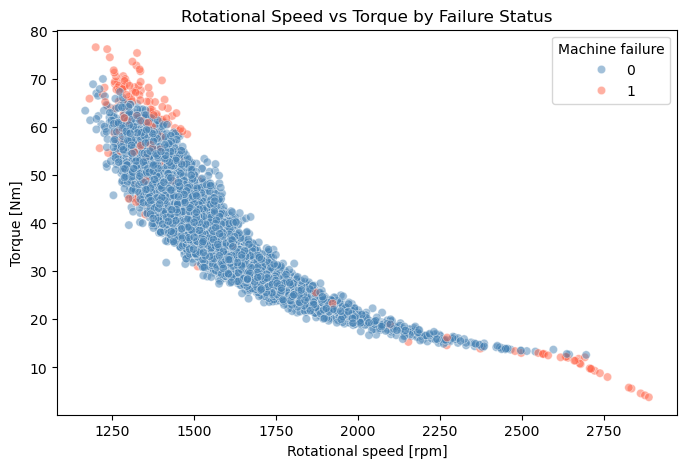

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Rotational speed [rpm]', 
                y='Torque [Nm]', 
                hue='Machine failure',
                alpha=0.5,
                palette=['steelblue', 'tomato'])
plt.title('Rotational Speed vs Torque by Failure Status')
plt.show()

**Finding:** The scatter plot reveals a clear pattern - failed machines 
(red) tend to cluster in two distinct zones: high torque/low speed 
and low torque/high speed regions. Normal machines (blue) dominate 
the central operating range. This suggests that machines operating 
outside their optimal torque-speed envelope are significantly more 
prone to failure.

### 5. Correlation Analysis

In [42]:
# Correlation
df[['Air temperature [K]', 'Process temperature [K]',
    'Rotational speed [rpm]', 'Torque [Nm]',
    'Tool wear [min]', 'Machine failure']].corr()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


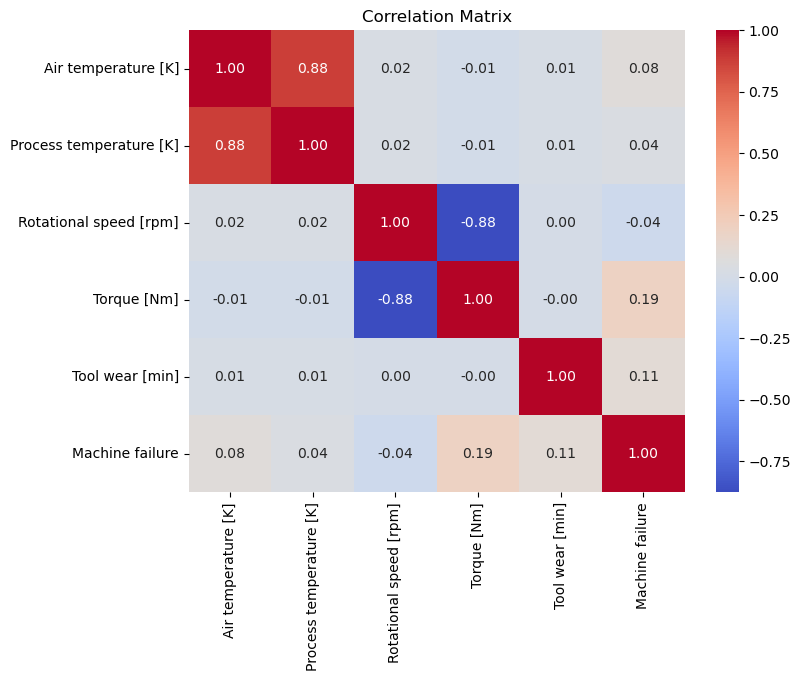

In [43]:
cols = ['Air temperature [K]', 'Process temperature [K]',
        'Rotational speed [rpm]', 'Torque [Nm]',
        'Tool wear [min]', 'Machine failure']

plt.figure(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Findings:** The heatmap reveals a strong positive correlation (0.88)
between Air Temperature and Process Temperature, which is physically 
expected as both are driven by the same heat source.

Additionally, there is a strong negative correlation between 
Rotational Speed and Torque (-0.88), consistent with the 
fundamental power equation: Power = Torque × RPM = constant.

In terms of Machine Failure, the strongest correlations are with 
Torque (0.19) and Tool Wear (0.11), suggesting these are the most 
promising features for predicting failure.

## 6. Key Findings & Conclusions

### Dataset Overview
The AI4I 2020 dataset contains 10,000 manufacturing records with 
14 features and no missing values, making it clean and ready for 
modelling.

### Key Findings

**1. Highly Imbalanced Target**  
Only 3.39% of records represent machine failures. This means 
standard accuracy will be misleading - F1-score and recall 
should be used as primary evaluation metrics.

**2. Most Common Failure Type**  
Heat Dissipation Failure (HDF) is the most frequent failure mode, 
which is consistent with known engineering causes of equipment 
degradation.

**3. Strong Predictive Features**  
- Tool Wear shows the clearest separation between failed and 
  normal machines - higher wear is associated with higher 
  failure risk
- Torque shows the strongest correlation with machine failure (0.19)
- Rotational Speed and Process temperature show lower average values in failed machines

**4. Feature Relationships**  
- Air Temperature and Process Temperature are strongly correlated, 
  suggesting one may be redundant for modelling
- Rotational Speed and Torque show strong negative correlation, 
  consistent with the fundamental power equation: 
  Power = Torque × RPM

### Conclusions & Next Steps
This EDA reveals that tool wear and torque are the most promising 
features for predicting machine failure. 

The class imbalance (3.39% failures) must be addressed before 
modelling - techniques such as SMOTE or class_weight='balanced' 
in sklearn are recommended.

**Recommended models to explore:**
- Logistic Regression (baseline)
- Random Forest (handles imbalance well)
- XGBoost (strong performance on tabular data)